In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

In [12]:
import os
os.listdir('/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new')

['test', 'train']

In [16]:
train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rescale = 1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True
)
test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

In [34]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (224,224),
    batch_size = 10,
    class_mode = 'categorical'
)

Found 640 images belonging to 4 classes.


In [36]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (224,224),
    batch_size = 10,
    class_mode = 'categorical'
)

Found 160 images belonging to 4 classes.


In [43]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

def build_model(input_shape=(224,224,3), num_classes=4):

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze VGG layers
    for layer in base_model.layers:
        layer.trainable = False

    # Custom classifier
    x = base_model.output
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    return model   

In [45]:
model = build_model()
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping 
early_stop = EarlyStopping(patience = 5,
                          restore_best_weights = True)

In [53]:
history = model.fit(
    train_generator,
    epochs = 25,
    validation_data = test_generator,
    
    
)

Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.4103 - loss: 1.2039 - val_accuracy: 0.3375 - val_loss: 11.5787
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.4415 - loss: 1.2117 - val_accuracy: 0.3375 - val_loss: 13.0467
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.5058 - loss: 1.1162 - val_accuracy: 0.3375 - val_loss: 15.5505
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.5401 - loss: 1.0493 - val_accuracy: 0.3313 - val_loss: 17.3092
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.5388 - loss: 1.0445 - val_accuracy: 0.3313 - val_loss: 17.3827
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.5597 - loss: 0.9758 - val_accuracy: 0.3375 - val_loss: 20.0990
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.5925 - loss: 0.9693 - val_accuracy: 0.3438 - val_loss: 19.6234
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.5760 - loss: 0.9607 - val_accur

In [58]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_vgg16(input_shape=(224,224,3), num_classes=5):

    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 2
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 3
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 4
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Block 5
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation='relu'))  # FC6
    model.add(layers.Dense(4096, activation='relu'))  # FC7
    model.add(layers.Dense(num_classes, activation='softmax'))  # FC8 replaced

    return model

In [ ]:
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=test_generator
)

Epoch 1/25


2026-03-26 11:48:44.925713: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 11:48:45.106426: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 11:48:45.857387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 11:48:46.018629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 11:48:47.529082: E external/local_xla/xla/stream_

64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 242ms/step - accuracy: 0.2510 - loss: 1.3873 - val_accuracy: 0.2812 - val_loss: 1.3853
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - accuracy: 0.2244 - loss: 1.3864 - val_accuracy: 0.2500 - val_loss: 1.3849
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step - accuracy: 0.2522 - loss: 1.3864 - val_accuracy: 0.2500 - val_loss: 1.3850
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 237ms/step - accuracy: 0.2440 - loss: 1.3864 - val_accuracy: 0.2625 - val_loss: 1.3849
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 241ms/step - accuracy: 0.2395 - loss: 1.3863 - val_accuracy: 0.2688 - val_loss: 1.3849
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 244ms/step - accuracy: 0.2224 - loss: 1.3864 - val_accuracy: 0.2500 - val_loss: 1.3849
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - accuracy: 0.2262 - loss: 1.3863 - val_accuracy: 0.2688 - val_loss: 1.3849
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 251ms/step - accuracy: 0.2605 - loss: 1.3863 - val_accuracy: 0.256

In [60]:
model = build_vgg16(input_shape=(224,224,3), num_classes=4)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔹 Data Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.3,
    brightness_range=[0.7,1.3],
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 🔥 MobileNet Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers[-50]:
    layer.trainable = True

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='tf.keras.optimizers.Adam(1e-5)', loss='categorical_crossentropy', metrics=['accuracy'])

# 🔥 Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

# 🔥 Test
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

model.evaluate(test_gen)

Found 512 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


TypeError: 'Conv2D' object is not iterable

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔥 DATA GENERATOR (FIXED)
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    brightness_range=[0.7,1.3],
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 🔥 MODEL (MobileNetV2)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Unfreeze last 50 layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# 🔥 COMPILE (FIXED)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 CALLBACK
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# 🔥 TRAIN
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop]
)

# 🔥 TEST GENERATOR (FIXED)
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    class_mode='categorical'
)

# 🔥 EVALUATE
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

Found 512 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 414ms/step - accuracy: 0.2081 - loss: 2.5021 - val_accuracy: 0.2344 - val_loss: 1.8807
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.2508 - loss: 2.2224 - val_accuracy: 0.2422 - val_loss: 1.7006
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step - accuracy: 0.2827 - loss: 2.0300 - val_accuracy: 0.2812 - val_loss: 1.6110
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.3311 - loss: 1.7792 - val_accuracy: 0.2500 - val_loss: 1.6475
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step - accuracy: 0.3257 - loss: 1.8105 - val_accuracy: 0.2344 - val_loss: 1.5833
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 256ms/step - accuracy: 0.3575 - loss: 1.6552 - val_accuracy: 0.3047 - val_loss: 1.5840
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 254ms/step - accuracy: 0.3720 - loss: 1.6012 - val_accuracy: 0.2969 - val_loss: 1.6081
Epoch 8/25
32/32 ━━━━

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔥 SIMPLE + STABLE AUGMENTATION
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 🔥 FEATURE EXTRACTOR (FREEZE FULLY)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False   # 🔥 MOST IMPORTANT

# 🔥 SIMPLE HEAD (NO OVERFITTING)
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 TRAIN
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

# 🔥 TEST
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

model.evaluate(test_gen)

Found 512 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 365ms/step - accuracy: 0.3172 - loss: 1.6157 - val_accuracy: 0.2734 - val_loss: 1.3795
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.4970 - loss: 1.1333 - val_accuracy: 0.3984 - val_loss: 1.2423
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step - accuracy: 0.5330 - loss: 1.0673 - val_accuracy: 0.4531 - val_loss: 1.1606
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.6321 - loss: 0.9079 - val_accuracy: 0.4844 - val_loss: 1.1389
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.6203 - loss: 0.9109 - val_accuracy: 0.5000 - val_loss: 1.3129
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step - accuracy: 0.6608 - loss: 0.8351 - val_accuracy: 0.4531 - val_loss: 1.1668
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.6766 - loss: 0.8375 - val_accuracy: 0.5469 - val_loss: 1.0956
Epoch 8/15
32/32 ━━━━

[0.9604392051696777, 0.5874999761581421]

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔥 DATA AUGMENTATION (balanced)
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 🔥 MODEL (EfficientNet = better than MobileNet for small data)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # first freeze

# 🔥 HEAD
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 CALLBACKS (IMPORTANT)
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

# 🔥 TRAIN (phase 1)
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

# 🔥 PHASE 2 (fine-tuning)
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

# 🔥 TEST
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

model.evaluate(test_gen)

Found 512 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 446ms/step - accuracy: 0.3476 - loss: 1.8213 - val_accuracy: 0.5078 - val_loss: 1.2016 - learning_rate: 0.0010
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.5513 - loss: 1.1499 - val_accuracy: 0.5078 - val_loss: 1.0970 - learning_rate: 0.0010
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.6730 - loss: 0.8860 - val_accuracy: 0.5703 - val_loss: 1.0786 - learning_rate: 0.0010
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.6798 - loss: 0.8023 - val_accuracy: 0.5000 - val_loss: 1.0437 - learning_rate: 0.0010
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.7583 - loss: 0.7025 - val_accuracy: 0.5391 - val_loss: 1.0012 - learning_rate: 0.0010
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.7599 - loss: 0.6046 - val_accuracy: 0.5625 - val_loss: 1.0035 - learning_rate: 0.0010
Epoch

[1.0680758953094482, 0.512499988079071]

In [9]:
import os

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"

for cls in os.listdir(train_dir):
    print(cls, len(os.listdir(os.path.join(train_dir, cls))))

1509_sella 160
1401_sella 160
1718_sella 160
Taaj_sella 160


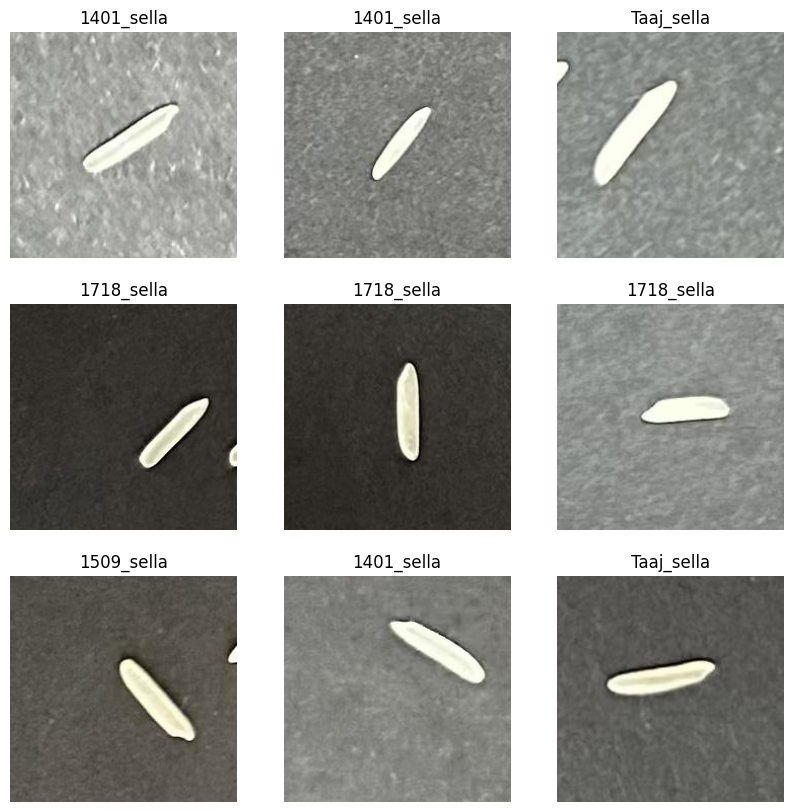

In [10]:
import matplotlib.pyplot as plt
import random
from PIL import Image

classes = os.listdir(train_dir)

plt.figure(figsize=(10,10))

for i in range(9):
    cls = random.choice(classes)
    img_path = random.choice(os.listdir(os.path.join(train_dir, cls)))
    
    img = Image.open(os.path.join(train_dir, cls, img_path))
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [11]:
from PIL import Image
sizes = set()
for cls in os.listdir(train_dir):
    for img_name in os.listdir(os.path.join(train_dir,cls))[:20]:
        img = Image.open(os.path.join(train_dir,cls,img_name))
        sizes.add(img.size)
print(sizes)

{(224, 224)}


In [12]:
from PIL import Image
bad = 0
for cls in os.listdir(train_dir):
    for img_name in os.listdir(os.path.join(train_dir,cls)):
        try:
            Image.open(os.path.join(train_dir,cls,img_name))
        except:
            bad += 1
print("Corrupt images: ",bad)

Corrupt images:  0


In [13]:
import hashlib

hashes = set()
duplicates = 0

for cls in os.listdir(train_dir):
    for img_name in os.listdir(os.path.join(train_dir, cls)):
        path = os.path.join(train_dir, cls, img_name)
        
        with open(path, 'rb') as f:
            filehash = hashlib.md5(f.read()).hexdigest()
        
        if filehash in hashes:
            duplicates += 1
        else:
            hashes.add(filehash)

print("Duplicates:", duplicates)

Duplicates: 2


In [14]:
import numpy as np

def merge_classes(generator):
    while True:
        x, y = next(generator)
        
        # y shape = (batch_size, 4)
        new_y = np.zeros((y.shape[0], 3))
        
        # class 0 → same
        new_y[:,0] = y[:,0]
        
        # class 1 + 3 merge
        new_y[:,1] = y[:,1] + y[:,3]
        
        # class 2 → same
        new_y[:,2] = y[:,2]
        
        yield x, new_y

In [20]:
train_gen_new = merge_classes(train_gen)
val_gen_new = merge_classes(val_gen)

In [21]:
Dense(3, activation='softmax')

NameError: name 'Dense' is not defined

In [22]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔥 DATA GENERATOR
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 🔥 CLASS MERGING FUNCTION (4 → 3)
def merge_classes(generator):
    while True:
        x, y = next(generator)
        
        # new labels (3 classes)
        new_y = np.zeros((y.shape[0], 3))
        
        # 0 → same
        new_y[:,0] = y[:,0]
        
        # 1 + 3 merge
        new_y[:,1] = y[:,1] + y[:,3]
        
        # 2 → same
        new_y[:,2] = y[:,2]
        
        yield x, new_y

train_gen_new = merge_classes(train_gen)
val_gen_new = merge_classes(val_gen)

# 🔥 MODEL
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(3, activation='softmax')(x)   # 🔥 3 classes

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 TRAIN
model.fit(
    train_gen_new,
    validation_data=val_gen_new,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen),
    epochs=15
)

# 🔥 TEST GENERATOR
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

# 🔥 TEST MERGE
test_gen_new = merge_classes(test_gen)

model.evaluate(test_gen_new, steps=len(test_gen))

Found 512 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 365ms/step - accuracy: 0.4986 - loss: 1.0928 - val_accuracy: 0.4844 - val_loss: 0.9715
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.6188 - loss: 0.8324 - val_accuracy: 0.6250 - val_loss: 0.9220
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.6817 - loss: 0.7023 - val_accuracy: 0.5625 - val_loss: 0.9092
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.6960 - loss: 0.7360 - val_accuracy: 0.5156 - val_loss: 0.9003
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.7040 - loss: 0.6764 - val_accuracy: 0.5391 - val_loss: 0.9652
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.7563 - loss: 0.5483 - val_accuracy: 0.4922 - val_loss: 1.0149
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.7023 - loss: 0.6631 - val_accuracy: 0.5781 - val_loss: 0.9892
Epoch 8/15
32/32 ━━━━

[0.986930251121521, 0.6000000238418579]

In [23]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔹 Data Generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 🔥 ANN Model
model_ann = Sequential([
    Flatten(input_shape=(224,224,3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')   # 🔥 4 classes
])

model_ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 Train
model_ann.fit(train_gen, validation_data=val_gen, epochs=10)

# 🔥 Test
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

model_ann.evaluate(test_gen)

Found 512 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.2163 - loss: 42.4749 - val_accuracy: 0.2578 - val_loss: 14.6488
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2759 - loss: 11.1689 - val_accuracy: 0.2734 - val_loss: 3.7554
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3899 - loss: 3.6000 - val_accuracy: 0.3906 - val_loss: 5.7039
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3837 - loss: 3.8707 - val_accuracy: 0.2500 - val_loss: 5.7371
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3648 - loss: 3.5664 - val_accuracy: 0.3359 - val_loss: 3.4035
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4368 - loss: 3.2732 - val_accuracy: 0.3203 - val_loss: 4.0795
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4225 - loss: 2.7963 - val_accuracy: 0.3281 - val_loss: 3.3696
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4262 - loss: 3.4200 - val_accuracy: 0.2656 - val_loss:

[2.8872008323669434, 0.4437499940395355]

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# 🔥 DNN Model
model_dnn = Sequential([
    Flatten(input_shape=(224,224,3)),
    
    Dense(256, activation='relu'),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    
    Dense(4, activation='softmax')   # 🔥 4 classes
])

model_dnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 Train
model_dnn.fit(train_gen, validation_data=val_gen, epochs=15)

# 🔥 Evaluate
model_dnn.evaluate(test_gen)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.2394 - loss: 33.1276 - val_accuracy: 0.2500 - val_loss: 8.4178
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2125 - loss: 16.6148 - val_accuracy: 0.2344 - val_loss: 1.8181
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2220 - loss: 1.6880 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2255 - loss: 1.3873 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2642 - loss: 1.3860 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.2852 - loss: 1.3854 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2322 - loss: 1.3864 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2742 - loss: 1.3862 - val_accuracy: 0.2500 -

[1.3863111734390259, 0.25]

In [25]:
import os
import numpy as np
import cv2
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

IMG_SIZE = 64   # 🔥 small size (SVM fast chalega)

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔹 Load Data
def load_data(folder):
    X = []
    y = []
    
    classes = os.listdir(folder)
    
    for label, cls in enumerate(classes):
        path = os.path.join(folder, cls)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            X.append(img.flatten())   # 🔥 flatten
            y.append(label)
    
    return np.array(X), np.array(y)

# 🔥 Load train + test
X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

# 🔹 Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# 🔥 SVM Model
model = SVC(kernel='linear', C=10)

model.fit(X_train, y_train)

# 🔥 Prediction
y_pred = model.predict(X_test)

# 🔥 Accuracy
acc = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", acc)

SVM Accuracy: 0.5375


In [26]:
import os
import numpy as np
import cv2
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

IMG_SIZE = 64

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔹 Load Data
def load_data(folder):
    X = []
    y = []
    
    classes = os.listdir(folder)
    
    for label, cls in enumerate(classes):
        path = os.path.join(folder, cls)
        
        for img_name in os.listdir(path):
            img = cv2.imread(os.path.join(path, img_name))
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            X.append(img.flatten())
            y.append(label)
    
    return np.array(X), np.array(y)

# 🔥 Load
X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

# 🔹 Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# 🔥 ✅ PCA YAHAN LAGANA HAI
pca = PCA(n_components=100)

X_train = pca.fit_transform(X_train)   # fit on train
X_test = pca.transform(X_test)         # only transform test

# 🔥 SVM
model = SVC(kernel='rbf', C=10)

model.fit(X_train, y_train)

# 🔥 Predict
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.48125


In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/train"
test_dir  = "/kaggle/input/datasets/madhvii0911/rice-classificatio/rice_dataset (1)/classification_224 new/test"

# 🔥 DATA GENERATOR (balanced + correct)
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 🔥 MODEL
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False   # first freeze

# 🔥 HEAD
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 CALLBACKS
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

# 🔥 TRAIN (PHASE 1)
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

# 🔥 PHASE 2 (fine-tuning)
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

# 🔥 TEST
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

model.evaluate(test_gen)

Found 512 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 437ms/step - accuracy: 0.3448 - loss: 1.9605 - val_accuracy: 0.4141 - val_loss: 1.3635 - learning_rate: 0.0010
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.5896 - loss: 1.1850 - val_accuracy: 0.4062 - val_loss: 1.2066 - learning_rate: 0.0010
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step - accuracy: 0.6764 - loss: 0.8119 - val_accuracy: 0.4531 - val_loss: 1.1183 - learning_rate: 0.0010
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.7144 - loss: 0.7045 - val_accuracy: 0.5469 - val_loss: 1.0086 - learning_rate: 0.0010
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step - accuracy: 0.7241 - loss: 0.7317 - val_accuracy: 0.5391 - val_loss: 1.0754 - learning_rate: 0.0010
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.7719 - loss: 0.6344 - val_accuracy: 0.5234 - val_loss: 1.0982 - learning_rate: 0.0010
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.7257 - loss: 0.6972 -

[1.2868068218231201, 0.4312500059604645]